# Reproduce Results: U-Net vs FNO on Kolmogorov Flow

This notebook loads trained model checkpoints and regenerates all figures and metrics reported in the paper. No retraining is required.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
os.chdir('/content/drive/MyDrive/Colab Notebooks/24788_project')
sys.path.insert(0, '.')

Mounted at /content/drive


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from dataset import KolmFlowDataset, KolmFlowRolloutDataset, get_data_splits
from models.unet import UNet
from models.fno import FNO2d
from utils import (
    Normalizer, nrmse_field, rollout_nrmse,
    plot_rollout_comparison, plot_vorticity_comparison, plot_tke_comparison,
    plot_training_curves
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Load Data and Normalizer

In [4]:
DATA_PATH = './data/KolmFlow_valid_256.h5'
CKPT_DIR = './checkpoints'
FIG_DIR = './figures'
os.makedirs(FIG_DIR, exist_ok=True)

train_idx, val_idx = get_data_splits(n_samples=256, n_train=200, seed=42)
normalizer = Normalizer.load('./data/normalizer.pt')
print(f'Normalizer: mean={normalizer.mean:.4f}, std={normalizer.std:.4f}')
print(f'Train samples: {len(train_idx)}, Val samples: {len(val_idx)}')

Normalizer: mean=-0.0000, std=3.5004
Train samples: 200, Val samples: 56


## Load Trained Models

In [5]:
def load_model(model_name, ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    if model_name == 'unet':
        model = UNet(in_channels=1, out_channels=1, base_channels=64)
    elif model_name == 'fno':
        model = FNO2d(modes1=16, modes2=16, width=32, n_layers=4)
    state_dict = {k.replace('_orig_mod.', ''): v for k, v in ckpt['model_state_dict'].items()}
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    print(f'Loaded {model_name} from epoch {ckpt["epoch"]} (val_loss={ckpt["val_loss"]:.6f})')
    return model

unet = load_model('unet', os.path.join(CKPT_DIR, 'best_unet.pt'), device)
fno = load_model('fno', os.path.join(CKPT_DIR, 'best_fno.pt'), device)

Loaded unet from epoch 50 (val_loss=0.000556)
Loaded fno from epoch 50 (val_loss=0.000613)


## 1. One-Step NRMSE

In [6]:
val_ds = KolmFlowDataset(DATA_PATH, val_idx, normalizer=normalizer, stride=2)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)

@torch.no_grad()
def eval_one_step(model, loader, device):
    model.eval()
    total_nrmse = 0.0
    n = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        total_nrmse += nrmse_field(pred, y) * x.shape[0]
        n += x.shape[0]
    return total_nrmse / n

nrmse_unet = eval_one_step(unet, val_loader, device)
nrmse_fno = eval_one_step(fno, val_loader, device)

print(f'One-Step NRMSE')
print(f'  U-Net: {nrmse_unet:.6f}')
print(f'  FNO:   {nrmse_fno:.6f}')

val_ds.close()

One-Step NRMSE
  U-Net: 0.022530
  FNO:   0.021635


## 2. Autoregressive Rollout

  Sample 0: U-Net final=554530.5625, FNO final=0.9235
  Sample 1: U-Net final=445.9427, FNO final=0.9445
  Sample 2: U-Net final=7555870.0000, FNO final=1.1225
  Sample 3: U-Net final=17593.4766, FNO final=0.8983
  Sample 4: U-Net final=314325.8750, FNO final=0.9004


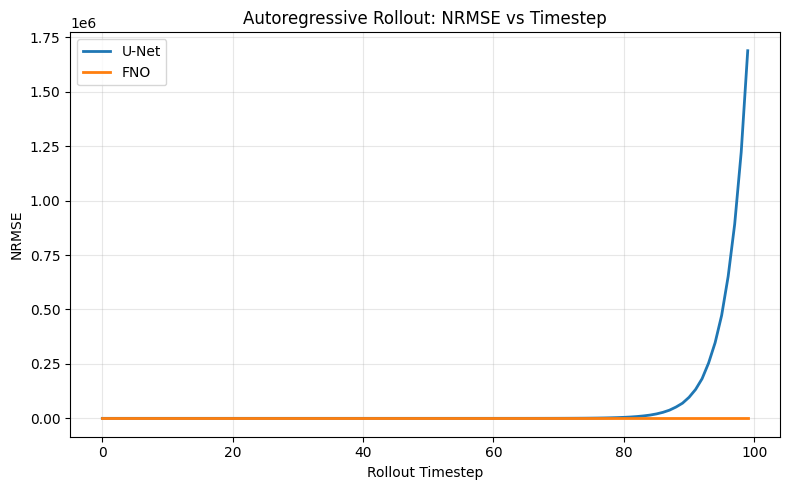


Rollout NRMSE at t=50:  U-Net=2.2382, FNO=0.5845
Rollout NRMSE at t=100: U-Net=1688553.1714, FNO=0.9578


In [7]:
rollout_ds = KolmFlowRolloutDataset(DATA_PATH, val_idx)
n_rollout_samples = 5
rollout_steps = 100

all_unet_rollouts = []
all_fno_rollouts = []

for i in range(n_rollout_samples):
    frames = rollout_ds[i]
    initial = frames[0].unsqueeze(0)
    gt_future = frames[1:]

    unet_nrmse = rollout_nrmse(unet, initial, gt_future, normalizer, device, rollout_steps)
    fno_nrmse_vals = rollout_nrmse(fno, initial, gt_future, normalizer, device, rollout_steps)

    all_unet_rollouts.append(unet_nrmse)
    all_fno_rollouts.append(fno_nrmse_vals)
    print(f'  Sample {i}: U-Net final={unet_nrmse[-1]:.4f}, FNO final={fno_nrmse_vals[-1]:.4f}')

avg_unet = np.mean(all_unet_rollouts, axis=0)
avg_fno = np.mean(all_fno_rollouts, axis=0)

plot_rollout_comparison(avg_unet, avg_fno, save_path=os.path.join(FIG_DIR, 'rollout_nrmse.png'))

print(f'\nRollout NRMSE at t=50:  U-Net={avg_unet[49]:.4f}, FNO={avg_fno[49]:.4f}')
print(f'Rollout NRMSE at t=100: U-Net={avg_unet[-1]:.4f}, FNO={avg_fno[-1]:.4f}')

## 3. Vorticity Field Visualizations

In [8]:
frames = rollout_ds[0]

for model, model_name in [(unet, 'U-Net'), (fno, 'FNO')]:
    for vis_step in [1, 10, 25, 50]:
        if vis_step >= frames.shape[0]:
            break

        model.eval()
        pred = frames[0].unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            for t in range(vis_step):
                inp = normalizer.encode(pred)
                pred = normalizer.decode(model(inp))

        gt = frames[vis_step].cpu().numpy()
        pr = pred.squeeze().cpu().numpy()

        plot_vorticity_comparison(
            pr, gt, timestep=vis_step, model_name=model_name,
            save_path=os.path.join(FIG_DIR, f'vorticity_{model_name.lower()}_t{vis_step}.png')
        )

Output hidden; open in https://colab.research.google.com to view.

## 4. Log-TKE Spectrum (Bonus Analysis)

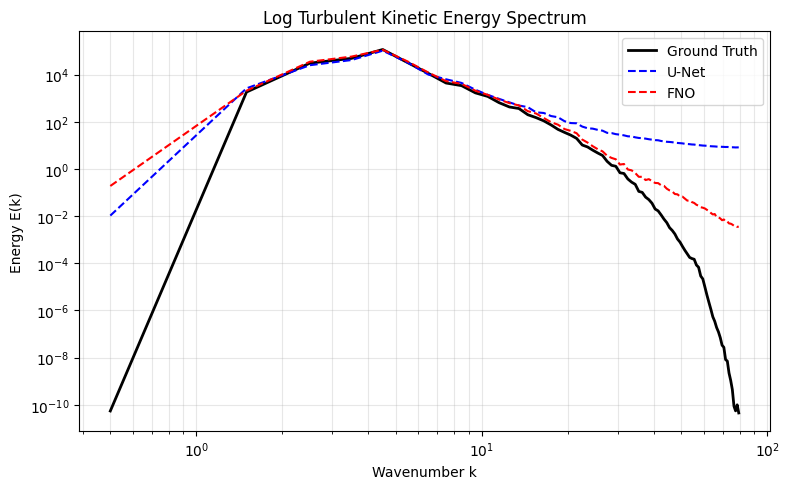

In [9]:
from utils import compute_energy_spectrum

tke_step = 20
gt_field = frames[tke_step].cpu().numpy()

tke_preds = {}
for model, name in [(unet, 'unet'), (fno, 'fno')]:
    pred = frames[0].unsqueeze(0).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        for t in range(tke_step):
            inp = normalizer.encode(pred)
            pred = normalizer.decode(model(inp))
    tke_preds[name] = pred.squeeze().cpu().numpy()

plot_tke_comparison(
    gt_field, tke_preds['unet'], tke_preds['fno'],
    save_path=os.path.join(FIG_DIR, 'tke_spectrum.png')
)

## Summary

In [10]:
print('=' * 55)
print('RESULTS SUMMARY')
print('=' * 55)
print(f'{"Metric":<30} {"U-Net":<12} {"FNO":<12}')
print('-' * 55)
print(f'{"One-step NRMSE":<30} {nrmse_unet:<12.6f} {nrmse_fno:<12.6f}')
print(f'{"Rollout NRMSE (t=50)":<30} {avg_unet[49]:<12.4f} {avg_fno[49]:<12.4f}')
print(f'{"Rollout NRMSE (t=100)":<30} {avg_unet[-1]:<12.4f} {avg_fno[-1]:<12.4f}')
print(f'{"Parameters":<30} {"7.70M":<12} {"2.10M":<12}')
print('=' * 55)
print(f'\nAll figures saved to: {FIG_DIR}')

rollout_ds.close()

RESULTS SUMMARY
Metric                         U-Net        FNO         
-------------------------------------------------------
One-step NRMSE                 0.022530     0.021635    
Rollout NRMSE (t=50)           2.2382       0.5845      
Rollout NRMSE (t=100)          1688553.1714 0.9578      
Parameters                     7.70M        2.10M       

All figures saved to: ./figures
